# To-do 
- Fix up data table in blog doc 
- Add section elaborating on drilling down (relate discarded stuff back to main stuff)
- Try another tree type (RandomForest?) and compare results 
- Include year of issuance in the analysis? 
- Talk about issues with the data 
- Make another tree with demolition-only permits 
- Give a little rundown of what's important in the general section 
- Put images into the doc 

In [1]:
import sys
print(sys.path)

['/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python313.zip', '/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13', '/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13/lib-dynload', '', '/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13/site-packages']


# All buildings

In [31]:
import requests
import pandas as pd
import io
from private_info.my_buildings import mapping, alt_mapping

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
url = base_url + "/api/3/action/package_show"
params = { "id": "building-permits-active-permits"}
package = requests.get(url, params = params, verify=False).json()

# To get resource data:
for idx, resource in enumerate(package["result"]["resources"]):

       # for datastore_active resources:
       if resource["datastore_active"]:

           # To get all records in CSV format:
           url = base_url + "/datastore/dump/" + resource["id"]
           resource_dump_data = requests.get(url, verify=False).text

           # To selectively pull records and attribute-level metadata:
           url = base_url + "/api/3/action/datastore_search"
           p = { "id": resource["id"] }
           resource_search_data = requests.get(url, params = p, verify=False).json()["result"]

       # To get metadata for non datastore_active resources:
       if not resource["datastore_active"]:
           url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
           resource_metadata = requests.get(url, verify=False).json()

# grad the data
df = pd.read_csv(io.StringIO(resource_dump_data))

/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ckan0.cf.opendata.inter.prod-toronto.ca'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ckan0.cf.opendata.inter.prod-toronto.ca'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/Caskroom/miniconda/base/envs/blogathon/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ckan0.cf.opendata.inter.prod-toronto.ca'. Adding certificate verifica

In [ ]:
"""
CREATING BUILDING VECTORS
"""
import re
from pathlib import Path
import pandas as pd
import numpy as np

# --- 1. LOAD DATA ---
current_folder = globals()['_dh'][0]
file_path = Path(current_folder).joinpath('large_files').joinpath('building-permits-active-permits.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

with open(file_path, 'r') as f:
    df = pd.read_csv(f)

# --- 2. RECREATE FULL_ADDRESS (Required since we just reloaded the CSV) ---
# Using the logic from your existing notebook to ensure consistency
for col in ['STREET_NUM', 'STREET_NAME', 'STREET_TYPE', 'STREET_DIRECTION', 'POSTAL']:
    df[col] = df[col].astype(str).fillna('').str.strip()

df['FULL_ADDRESS'] = (
    df['STREET_NUM'] + ' ' +
    df['STREET_NAME'] + ' ' +
    df['STREET_TYPE'] + ' ' +
    df['STREET_DIRECTION']
).str.strip() + ', ' + df['POSTAL']

# Drop columns (as per your snippet)
drop_cols = ['_id', 'GEO_ID', 'WARD_GRID']
df.drop(columns=[c for c in drop_cols if c in df.columns], axis=1, inplace=True)

# --- 3. CLEAN NUMERIC DATA ---
# Clean Application Year
df['APPLICATION_YEAR'] = pd.to_datetime(df['APPLICATION_DATE'], errors='coerce').dt.year

# >>> ADD THESE TWO LINES <<<
# Clean Issued Year
df['ISSUED_DATE'] = pd.to_datetime(df['ISSUED_DATE'], errors='coerce')
df['ISSUED_YEAR'] = df['ISSUED_DATE'].dt.year
# >>> END ADDITION <<<

df = df[df['APPLICATION_YEAR'] >= 2005] # exclude data from before 2005

# Clean Estimated Cost
# CHANGE: Fill NaN with 0 instead of -999 so it sums correctly
df['EST_CONST_COST'] = pd.to_numeric(df['EST_CONST_COST'], errors='coerce').fillna(0)
df['DWELLING_UNITS_CREATED'] = pd.to_numeric(df['DWELLING_UNITS_CREATED'], errors='coerce').fillna(0)
df['DWELLING_UNITS_LOST'] = pd.to_numeric(df['DWELLING_UNITS_LOST'], errors='coerce').fillna(0)

# --- 4. CLEAN CATEGORICAL DATA ---
col_names = ['WORK', 'STRUCTURE_TYPE', 'PERMIT_TYPE', 'BUILDER_NAME', 'PROPOSED_USE', 'CURRENT_USE']
threshold = 0.01

for col in col_names:
    if col in df.columns:
        # Lump uncommon categories into "Other"
        value_freqs = df[col].value_counts(normalize=True)
        rare_categories = value_freqs[value_freqs < threshold].index
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
        
        # Optional: Print summary as requested
        # print(f"\nMost common values of column {col}:")
        # print(df[col].value_counts().head(3))

# Custom Feature: Count "Demolition" in description
def count_demolition(desc):
    if not isinstance(desc, str): return 0
    return len(re.findall(r'\bdemolition\b', desc, flags=re.IGNORECASE))

df['DEMO'] = df['DESCRIPTION'].apply(count_demolition)

# --- 5. ONE-HOT ENCODING (The Fix) ---
# Instead of frequency encoding (which loses the 'type' of permit during aggregation),
# we use One-Hot Encoding to create binary columns (e.g., PERMIT_TYPE_New House).
df_encoded = pd.get_dummies(df, columns=col_names, prefix=col_names, dummy_na=False)

# --- 6. AGGREGATION ---
# Define how to aggregate each column
numeric_cols_to_sum = ['EST_CONST_COST', 'DWELLING_UNITS_CREATED', 'DWELLING_UNITS_LOST', 'DEMO']
# Select all the new one-hot columns to be summed
ohe_cols = [c for c in df_encoded.columns if any(c.startswith(prefix) for prefix in col_names)]

agg_dict = {
    **{col: 'sum' for col in numeric_cols_to_sum},
    **{col: 'sum' for col in ohe_cols},
    'APPLICATION_YEAR': 'max',
    'ISSUED_YEAR': 'max'            
}

print("Grouping by address... this may take a moment.")
building_vectors = df_encoded.groupby("FULL_ADDRESS").agg(agg_dict).reset_index()

# Add a "Total Permits" feature by counting occurrences in the original df
permit_counts = df['FULL_ADDRESS'].value_counts()
building_vectors['TOTAL_PERMITS'] = building_vectors['FULL_ADDRESS'].map(permit_counts)

print(f"Created building vectors for {len(building_vectors)} unique addresses.")
print(building_vectors.head())

/var/folders/sx/y9bjmstd01v934672trl0m9m0000gn/T/ipykernel_9519/284050747.py:15: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Grouping by address... this may take a moment.
Created building vectors for 72495 unique addresses.
           FULL_ADDRESS  APPLICATION_YEAR  ISSUED_YEAR  EST_CONST_COST  \
0  0 ABRAHAM WELSH RD,               2024       2024.0             0.0   
1     0 ADELAIDE ST W,               2025       2025.0       8000000.0   
2        0 AUKLAND RD,               2023       2023.0        120000.0   
3  0 BARBER GREENE RD,               2020       2020.0             0.0   
4        0 BARKWIN DR,               2014       2014.0         60000.0   

   DWELLING_UNITS_CREATED  DWELLING_UNITS_LOST  DEMO  \
0                     0.0                  0.0     0   
1                     0.0                  0.0     0   
2                     0.0                  0.0     0   
3                     0.0                  0.0     0   
4                     0.0                  0.0     0   

   WORK_ Backflow Prevention Devices (Water only)  WORK_Addition(s)   \
0                                             

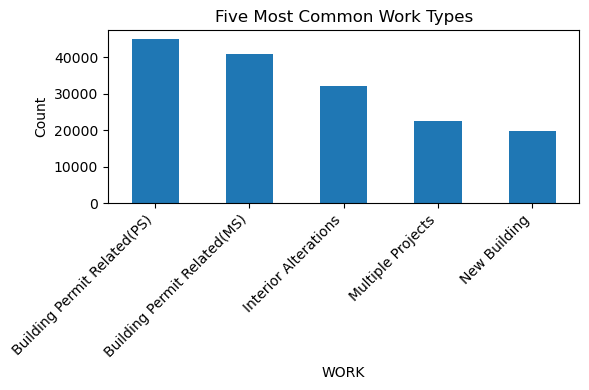

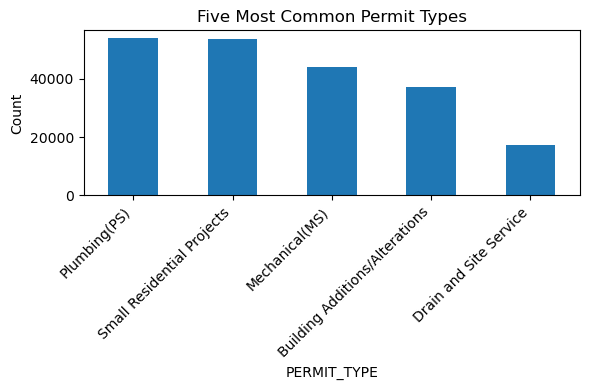

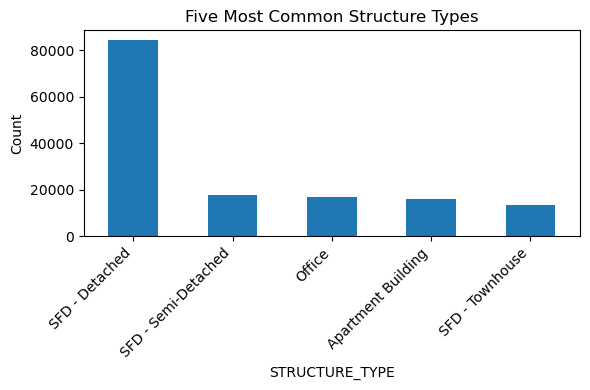

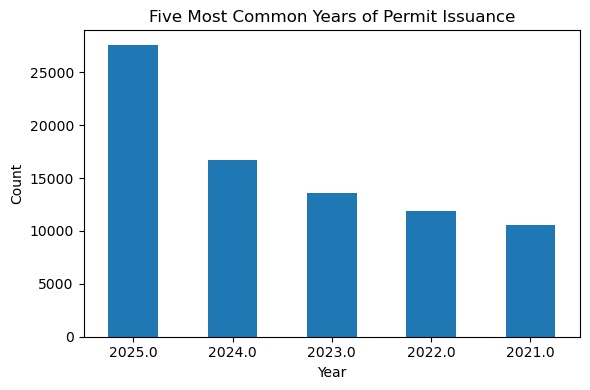

In [32]:
# summarise the data in the active building permits dataset

import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
df["ISSUED_DATE"] = pd.to_datetime(df["ISSUED_DATE"], errors="coerce")
df["APPLICATION_DATE"] = pd.to_datetime(df["APPLICATION_DATE"], errors="coerce")
df["COMPLETED_DATE"] = pd.to_datetime(df["COMPLETED_DATE"], errors="coerce")

# Extract years
df["ISSUED_YEAR"] = df["ISSUED_DATE"].dt.year
df["APPLICATION_YEAR"] = df["APPLICATION_DATE"].dt.year

# Plot top Work types
work_counts = df["WORK"].value_counts()
plt.figure(figsize=(6,4))
work_counts = work_counts.head(5)
work_counts.plot(kind="bar")
plt.title("Five Most Common Work Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top Permit types
permit_counts = df["PERMIT_TYPE"].value_counts()
plt.figure(figsize=(6,4))
permit_counts = permit_counts.head(5)
permit_counts.plot(kind="bar")
plt.title("Five Most Common Permit Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top structure types
structure_counts = df["STRUCTURE_TYPE"].value_counts()
plt.figure(figsize=(6,4))
structure_counts = structure_counts.head(5)
structure_counts.plot(kind="bar")
plt.title("Five Most Common Structure Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot issuance year trend
year_counts = df["ISSUED_YEAR"].value_counts()
plt.figure(figsize=(6,4))
year_counts = year_counts.head(5)
year_counts.plot(kind="bar")
plt.title("Five Most Common Years of Permit Issuance")
plt.ylabel("Count")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [33]:
# summarise the data in the active building permits dataset

import pandas as pd

# Define the columns we want to summarize and their display names
categories = {
    "WORK": "Work Type",
    "PERMIT_TYPE": "Permit Type",
    "STRUCTURE_TYPE": "Structure Type",
    "ISSUED_YEAR": "Issued Year"
}

summary_data = {}

for col, name in categories.items():
    # Calculate the top 5 value counts for the column
    counts = df[col].value_counts().head(5)
    
    # Add the categories and their counts to our data dictionary
    # We use lists to ensure they fit into the DataFrame columns
    summary_data[name] = counts.index.tolist()
    summary_data[f"{name} Count"] = counts.values.tolist()

# Create a single DataFrame from the dictionary
summary_table = pd.DataFrame(summary_data)

# Display the big table
print("Top 5 Active Building Permit Stats:")
print(summary_table)

# If you are running this in a Jupyter Notebook, you can just write:
# summary_table

Top 5 Active Building Permit Stats:
                     Work Type  Work Type Count  \
0  Building Permit Related(PS)            45052   
1  Building Permit Related(MS)            40723   
2         Interior Alterations            31997   
3            Multiple Projects            22400   
4                 New Building            19633   

                      Permit Type  Permit Type Count       Structure Type  \
0                    Plumbing(PS)              53828       SFD - Detached   
1      Small Residential Projects              53705  SFD - Semi-Detached   
2                  Mechanical(MS)              44092               Office   
3  Building Additions/Alterations              37052   Apartment Building   
4          Drain and Site Service              17233      SFD - Townhouse   

   Structure Type Count  Issued Year  Issued Year Count  
0                 84287       2025.0              27596  
1                 17711       2024.0              16697  
2                 16

In [34]:
# --- STEP 1: Define the masks first ---
# Replace 'COMPLETED_DATE' with the actual name of your date column (e.g., 'COMPLETED_DATE')
# Ensure the column is in datetime format first
df['COMPLETED_DATE'] = pd.to_datetime(df['COMPLETED_DATE'])

after_mask = df['COMPLETED_DATE'] >= '2023-01-01'
before_mask = df['COMPLETED_DATE'] < '2023-01-01'

# --- STEP 2: Your existing code ---
# Note: I added 'STREET_DIRECTION' to this list. 
# If you don't clean it, the concatenation below will result in NaN if the direction is missing.
cols_to_clean = ['STREET_NUM', 'STREET_NAME', 'STREET_TYPE', 'POSTAL', 'STREET_DIRECTION']

for col in cols_to_clean:
    # Check if column exists to avoid errors
    if col in df.columns:
        df[col] = df[col].astype(str).fillna('').str.strip()

df['FULL_ADDRESS'] = (
    df['STREET_NUM'] + ' ' +
    df['STREET_NAME'] + ' ' +
    df['STREET_TYPE'] + ' ' +
    df['STREET_DIRECTION']
).str.strip() + ', ' + df['POSTAL']

# Now this will work because the masks are defined
after_counts = df[after_mask].groupby('FULL_ADDRESS').size().rename('AFTER_2023')
before_counts = df[before_mask].groupby('FULL_ADDRESS').size().rename('BEFORE_2023')

# Cleanup
drop_cols = ['POSTAL', 'STREET_DIRECTION', 'STREET_TYPE', 'STREET_NAME', 'STREET_NUM']
df.drop(columns=drop_cols, axis=1, inplace=True)

print(df.describe())

                 _id   REVISION_NUM        GEO_ID  \
count  241833.000000  241833.000000  2.341270e+05   
mean   120917.000000       0.124044  6.187291e+06   
min         1.000000       0.000000  1.000000e+00   
25%     60459.000000       0.000000  7.738940e+05   
50%    120917.000000       0.000000  4.915751e+06   
75%    181375.000000       0.000000  9.530840e+06   
max    241833.000000      18.000000  6.001916e+07   
std     69811.318162       0.436946  6.751066e+06   

                    APPLICATION_DATE                    ISSUED_DATE  \
count                         241833                         226892   
mean   2016-05-21 07:00:50.866507264  2016-04-06 10:15:19.119228416   
min              1979-06-21 00:00:00            1979-11-27 00:00:00   
25%              2010-10-14 00:00:00            2010-07-26 00:00:00   
50%              2017-12-13 00:00:00            2017-08-17 00:00:00   
75%              2023-04-25 00:00:00            2023-03-31 00:00:00   
max              2026-01-

In [35]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from private_info.my_buildings import search_terms, mapping, alt_mapping

# --- STEP 1: DYNAMIC AGGREGATION RULES ---
# 1. Start by telling pandas to SUM every single numeric column found in 'df'
numeric_cols = df.select_dtypes(include=['number']).columns
agg_rules = {col: 'sum' for col in numeric_cols}

# 2. Override specific rules for Dates and IDs
special_rules = {
    'APPLICATION_YEAR': 'max', 
    'ISSUED_YEAR': 'max',
    'REVISION_NUM': 'max',
    'PERMIT_NUM': 'count' 
}
agg_rules.update(special_rules)

# --- STEP 2: CREATE MAIN DATASET (df_grouped) ---
# 3. Create the main dataset using these comprehensive rules
df_grouped = df.groupby("FULL_ADDRESS").agg(agg_rules).reset_index()

if 'PERMIT_NUM' in df_grouped.columns:
    df_grouped.rename(columns={'PERMIT_NUM': 'TOTAL_PERMITS'}, inplace=True)

# 4. Merge the Before/After counts (ONLY ONCE)
df_grouped = df_grouped.merge(before_counts.rename('BEFORE_2023'), on='FULL_ADDRESS', how='left')
df_grouped = df_grouped.merge(after_counts.rename('AFTER_2023'), on='FULL_ADDRESS', how='left')

# Fill NaNs with 0
df_grouped['BEFORE_2023'] = df_grouped['BEFORE_2023'].fillna(0)
df_grouped['AFTER_2023'] = df_grouped['AFTER_2023'].fillna(0)

# --- STEP 3: PREPARE SUBSET (building_vectors) ---
# 1. Search the ORIGINAL DataFrame
pattern = '|'.join(search_terms)
filtered_df = df[df['PERMIT_NUM'].str.contains(pattern, case=False, na=False)].copy()

# 2. Group and Aggregate using the SAME rules
# FIX: Changed 'actual_rules' to 'agg_rules' to match Step 1
building_vectors = filtered_df.groupby("FULL_ADDRESS").agg(agg_rules).reset_index()

if 'PERMIT_NUM' in building_vectors.columns:
    building_vectors.rename(columns={'PERMIT_NUM': 'TOTAL_PERMITS'}, inplace=True)

# --- STEP 4: MAPPING & CLEANING ---
building_vectors["cluster_label"] = building_vectors["FULL_ADDRESS"].map(mapping)
building_vectors = building_vectors.dropna(subset=['cluster_label'])

# --- STEP 5: FEATURE SELECTION ---
feature_names = [
    x for x in building_vectors.columns 
    if x not in ["cluster_label", 'PERMIT_NUM', 'FULL_ADDRESS']
]

# Calculate features
encoded_features = building_vectors[feature_names]

# Fill NaNs created by 'max' aggregation (e.g. missing Issued Years)
encoded_features = encoded_features.fillna(0)

target = LabelEncoder().fit_transform(building_vectors["cluster_label"])

info_gain = mutual_info_classif(
    encoded_features, 
    target, 
    discrete_features='auto', 
    random_state=100
)

result = pd.DataFrame({
        "feature": feature_names,
        "information_gain": info_gain
    }).sort_values(by="information_gain", ascending=False).reset_index(drop=True)

print(result)

                           feature  information_gain
0                           GEO_ID          0.359865
1                       MERCANTILE          0.269542
2   BUSINESS_AND_PERSONAL_SERVICES          0.181172
3                         ASSEMBLY          0.177753
4                    INSTITUTIONAL          0.072258
5           DWELLING_UNITS_CREATED          0.014841
6                              _id          0.000000
7                     REVISION_NUM          0.000000
8              DWELLING_UNITS_LOST          0.000000
9                      RESIDENTIAL          0.000000
10                      INDUSTRIAL          0.000000
11            INTERIOR_ALTERATIONS          0.000000
12                      DEMOLITION          0.000000
13                     ISSUED_YEAR          0.000000
14                APPLICATION_YEAR          0.000000
15                   TOTAL_PERMITS          0.000000


## Plots of own buildings

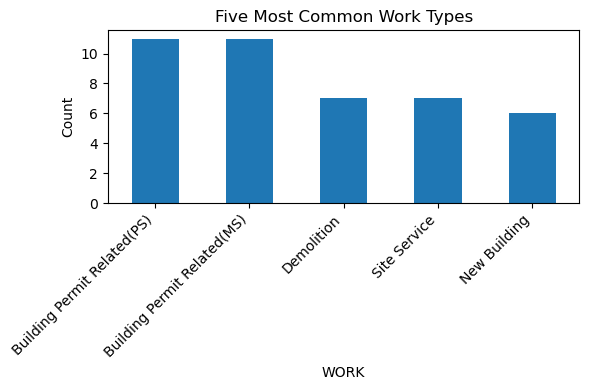

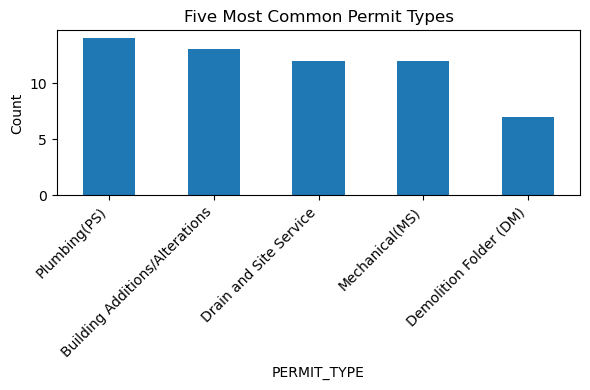

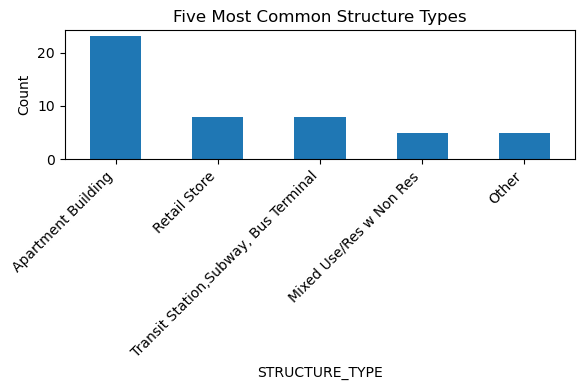

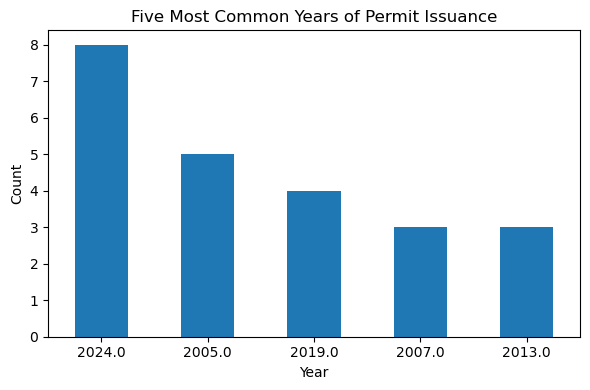

In [36]:
# summarise the data in the active building permits dataset

import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
filtered_df["ISSUED_DATE"] = pd.to_datetime(filtered_df["ISSUED_DATE"], errors="coerce")
filtered_df["APPLICATION_DATE"] = pd.to_datetime(filtered_df["APPLICATION_DATE"], errors="coerce")
filtered_df["COMPLETED_DATE"] = pd.to_datetime(filtered_df["COMPLETED_DATE"], errors="coerce")

# Extract years
filtered_df["ISSUED_YEAR"] = filtered_df["ISSUED_DATE"].dt.year
filtered_df["APPLICATION_YEAR"] = filtered_df["APPLICATION_DATE"].dt.year

# Plot top Work types
work_counts = filtered_df["WORK"].value_counts()
plt.figure(figsize=(6,4))
work_counts = work_counts.head(5)
work_counts.plot(kind="bar")
plt.title("Five Most Common Work Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top Permit types
permit_counts = filtered_df["PERMIT_TYPE"].value_counts()
plt.figure(figsize=(6,4))
permit_counts = permit_counts.head(5)
permit_counts.plot(kind="bar")
plt.title("Five Most Common Permit Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top structure types
structure_counts = filtered_df["STRUCTURE_TYPE"].value_counts()
plt.figure(figsize=(6,4))
structure_counts = structure_counts.head(5)
structure_counts.plot(kind="bar")
plt.title("Five Most Common Structure Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot issuance year trend
year_counts = filtered_df["ISSUED_YEAR"].value_counts()
plt.figure(figsize=(6,4))
year_counts = year_counts.head(5)
year_counts.plot(kind="bar")
plt.title("Five Most Common Years of Permit Issuance")
plt.ylabel("Count")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [37]:
# summarise the data in the active building permits dataset

import pandas as pd

categories = {
    "WORK": "Work Type",
    "PERMIT_TYPE": "Permit Type",
    "STRUCTURE_TYPE": "Structure Type",
    "ISSUED_YEAR": "Issued Year"
}

summary_data = {}

for col, name in categories.items():
    # Get the top 5 items (index) only, ignoring the specific counts
    top_items = filtered_df[col].value_counts().head(5).index.tolist()
    summary_data[name] = top_items

# Create the DataFrame
summary_table = pd.DataFrame(summary_data)

# Add a Rank column (1-5) at the start
summary_table.insert(0, "Rank", range(1, 6))

# Display the table
print("Top 5 Stats (filtered_df):")
print(summary_table)

# If in Jupyter, just write:
# summary_table

Top 5 Stats (filtered_df):
   Rank                    Work Type                     Permit Type  \
0     1  Building Permit Related(PS)                    Plumbing(PS)   
1     2  Building Permit Related(MS)  Building Additions/Alterations   
2     3                   Demolition          Drain and Site Service   
3     4                 Site Service                  Mechanical(MS)   
4     5                 New Building          Demolition Folder (DM)   

                         Structure Type  Issued Year  
0                    Apartment Building       2024.0  
1                          Retail Store       2005.0  
2  Transit Station,Subway, Bus Terminal       2019.0  
3               Mixed Use/Res w Non Res       2007.0  
4                                 Other       2013.0  


## PCA

Cluster 2: points=6, mean dist=5.512, std dist=1.636
Cluster 1: points=5, mean dist=4.985, std dist=2.050
Cluster 3: points=2, mean dist=6.466, std dist=0.000
Cluster 4: points=1, mean dist=nan, std dist=nan


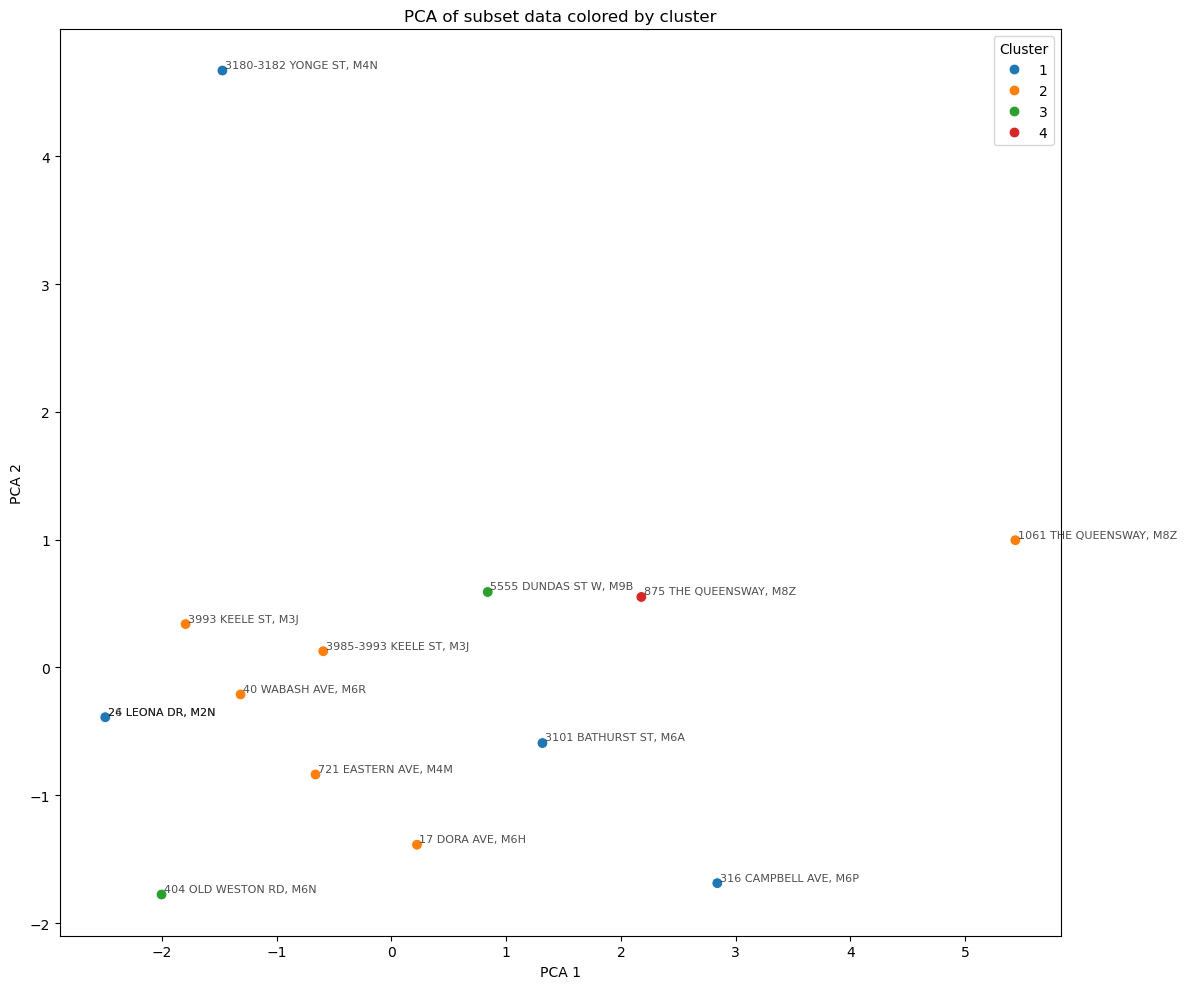

In [38]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

subset_df_scaled = building_vectors.copy()

subset_df_scaled[feature_names] = subset_df_scaled[feature_names].fillna(0)

scaler = StandardScaler()
# Now this won't crash
subset_df_scaled[feature_names] = scaler.fit_transform(subset_df_scaled[feature_names])

# Dictionary to hold cluster stats
cluster_stats = {}

for cluster in subset_df_scaled['cluster_label'].unique():
    cluster_data = subset_df_scaled[subset_df_scaled['cluster_label'] == cluster]
    if len(cluster_data) > 1: # big-clusters
        dist_matrix = pairwise_distances(cluster_data[feature_names], metric='euclidean')
        # avoid zero distances
        dists = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
        cluster_stats[cluster] = {
            'mean_distance': np.mean(dists),
            'std_distance': np.std(dists),
            'num_points': len(cluster_data)
        }
    else: # Single point cluster: distances undefined
        cluster_stats[cluster] = {
            'mean_distance': np.nan,
            'std_distance': np.nan,
            'num_points': 1
        }

# Print cluster stats
for cluster, stats in cluster_stats.items():
    print(f"Cluster {cluster}: points={stats['num_points']}, mean dist={stats['mean_distance']:.3f}, std dist={stats['std_distance']:.3f}")

# Visualize in low dimensions. There's not great separation, sadly, but whatevs
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(subset_df_scaled[feature_names])
subset_df_scaled['pca1'] = coords_2d[:, 0]
subset_df_scaled['pca2'] = coords_2d[:, 1]

# Plot with cluster coloring
plt.figure(figsize=(12, 10))
sns.scatterplot(data=subset_df_scaled, x='pca1', y='pca2', hue='cluster_label', palette='tab10', s=60)

# Add ADDRESS labels to each point
for _, row in subset_df_scaled.iterrows():
    # Added a slight check to ensure address is a string to prevent errors
    address_label = str(row['FULL_ADDRESS'])
    plt.text(row['pca1'] + 0.02, row['pca2'] + 0.02, address_label, fontsize=8, alpha=0.7)

plt.title('PCA of subset data colored by cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Decision Tree Classifier

Training Accuracy: 0.9285714285714286
y_train: 0     2
1     2
2     1
3     1
4     1
5     1
6     1
7     2
8     2
9     2
10    3
11    3
12    2
13    4
Name: cluster_label, dtype: int64
predictions: [2 2 1 1 1 1 1 3 2 2 3 3 2 4]
       predicted_class  confidence      _id  REVISION_NUM       GEO_ID  \
70987                1    1.000000    69518             0    8731638.0   
40571                1    1.000000   263683             0   21518128.0   
64268                1    1.000000    67077             0   10599186.0   
48926                2    1.000000    26998             0    7955810.0   
39484                2    1.000000  1894696             1  510170136.0   
14698                2    1.000000   186101             0   20448630.0   
66453                3    0.666667   514587             0   42934734.0   
68954                3    0.666667   755538             0   30348824.0   
48220                3    0.666667   326402             0   28603262.0   
67761                4  

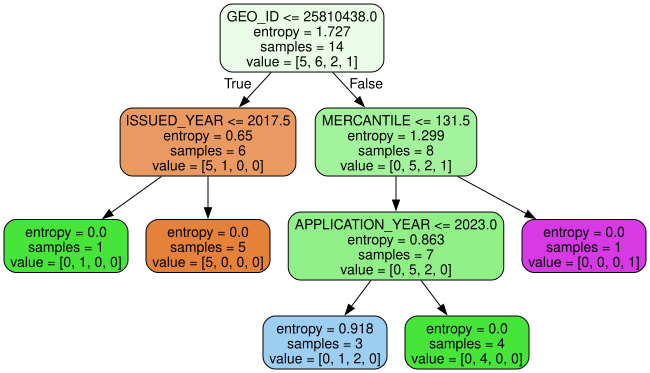

In [39]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# the buildings in the beautiful data set
X_train = building_vectors[feature_names].copy()
y_train = building_vectors['cluster_label'].copy()

# the ENTIRE data set
X_test = df_grouped[feature_names].copy()
addresses = df_grouped["FULL_ADDRESS"]

# limit the depth of the tree to 3 to avoid overfitting.
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))

predictions = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions}")

# Get predicted probabilities for each class
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

# Build a result DataFrame with predictions and confidence
results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

top_n = 3
top_confident_per_class = []

# Loop through each class
for cls, group in results.groupby('predicted_class'):
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    # Randomly select n samples
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

top_confident_per_class = pd.concat(top_confident_per_class)

print(top_confident_per_class)

dot_data = treeViz.export_graphviz(model, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))


## Random Forest 

Training Accuracy: 1.0
y_train: 0     2
1     2
2     1
3     1
4     1
5     1
6     1
7     1
8     2
9     2
10    2
11    3
12    3
13    2
14    4
Name: cluster_label, dtype: int64
predictions: [2 2 1 1 1 1 1 1 2 2 2 3 3 2 4]
       predicted_class  confidence  REVISION_NUM  DWELLING_UNITS_CREATED  \
13564                1    0.783683             0                   217.0   
68251                2    0.809087             0                    20.0   
60050                3    0.527004             1                     0.0   
55206                3    0.527004             0                     0.0   
7170                 3    0.527004             0                     0.0   
68803                4    0.544167             0                   152.0   

       DWELLING_UNITS_LOST  EST_CONST_COST  ASSEMBLY  INSTITUTIONAL  \
13564                  1.0         10000.0     868.9            0.0   
68251                  0.0       6000000.0       0.0            0.0   
60050                  

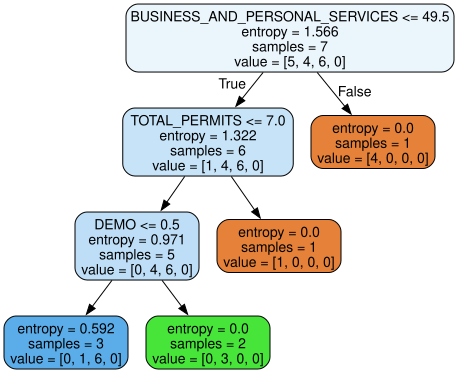

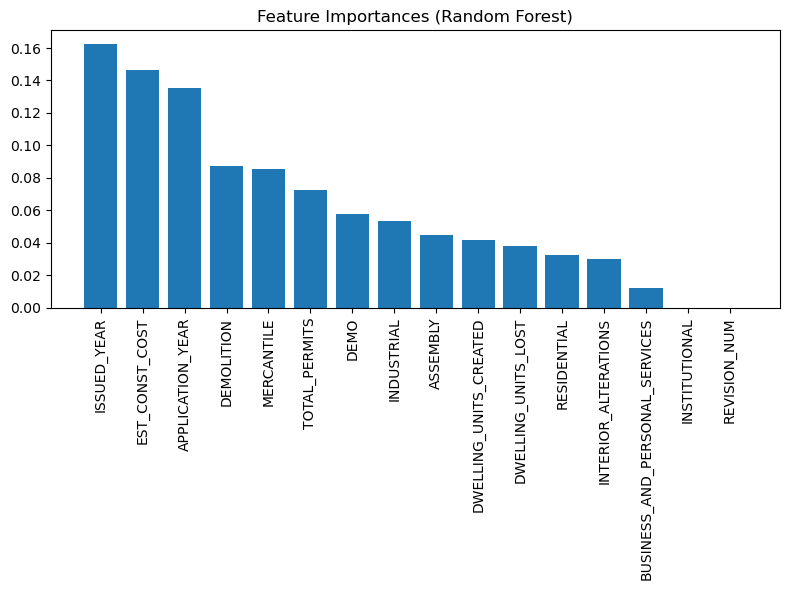

In [23]:
import pandas as pd
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# the buildings in the beautiful data set
X_train = building_vectors[feature_names].copy()
y_train = building_vectors['cluster_label'].copy()

# the ENTIRE data set
X_test = df_grouped[feature_names].copy()
addresses = df_grouped["FULL_ADDRESS"]

# limit the depth of the tree to 3 to avoid overfitting.
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, criterion='entropy')
model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))

predictions = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions}")

# Get predicted probabilities for each class
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

# Build a result DataFrame with predictions and confidence
results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

top_n = 3
top_confident_per_class = []

# Loop through each class
for cls, group in results.groupby('predicted_class'):
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    # Randomly select n samples
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

top_confident_per_class = pd.concat(top_confident_per_class)

print(top_confident_per_class)

# Visualize a single tree from the RandomForest
estimator = model.estimators_[50]
dot_data = treeViz.export_graphviz(estimator, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))

# Alternative: Feature importance plot for the whole forest
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


Training Accuracy: 1.0
y_train: 0     2
1     2
2     1
3     1
4     1
5     1
6     1
7     1
8     2
9     2
10    2
11    3
12    3
13    2
14    4
Name: cluster_label, dtype: int64
predictions: [2 2 1 1 1 1 1 1 2 2 2 3 3 2 4]
       predicted_class  confidence  REVISION_NUM  DWELLING_UNITS_CREATED  \
13564                1    0.766616             0                   217.0   
68251                2    0.794312             0                    20.0   
60050                3    0.484313             1                     0.0   
55206                3    0.484313             0                     0.0   
7170                 3    0.484313             0                     0.0   
68803                4    0.498409             0                   152.0   

       DWELLING_UNITS_LOST  EST_CONST_COST  ASSEMBLY  INSTITUTIONAL  \
13564                  1.0         10000.0     868.9            0.0   
68251                  0.0       6000000.0       0.0            0.0   
60050                  

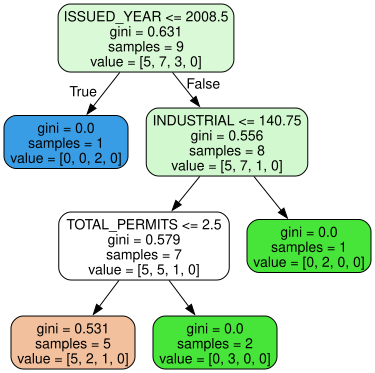

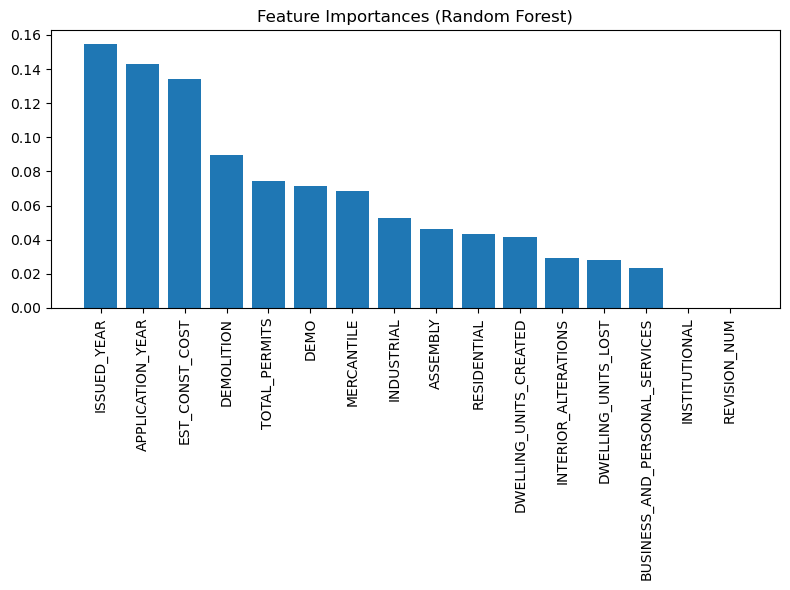

In [24]:
import pandas as pd
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# the buildings in the beautiful data set
X_train = building_vectors[feature_names].copy()
y_train = building_vectors['cluster_label'].copy()

# the ENTIRE data set
X_test = df_grouped[feature_names].copy()
addresses = df_grouped["FULL_ADDRESS"]

# limit the depth of the tree to 3 to avoid overfitting.
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))

predictions = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions}")

# Get predicted probabilities for each class
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

# Build a result DataFrame with predictions and confidence
results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

top_n = 3
top_confident_per_class = []

# Loop through each class
for cls, group in results.groupby('predicted_class'):
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    # Randomly select n samples
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

top_confident_per_class = pd.concat(top_confident_per_class)

print(top_confident_per_class)

# Visualize a single tree from the RandomForest
estimator = model.estimators_[0]
dot_data = treeViz.export_graphviz(estimator, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))

# Alternative: Feature importance plot for the whole forest
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


# Demolition only

In [41]:
import pandas as pd
import re

# Define your search pattern
from private_info.my_buildings import search_terms, mapping, alt_mapping
pattern = '|'.join(search_terms)

# 1. Filter for "Demolition Folder (DM)" permit type
demolition_desc_df = df[df['PERMIT_TYPE'] == 'Demolition Folder (DM)'].copy()

# 3. Further filter for permits matching the search terms
filtered_demolition_df = demolition_desc_df[demolition_desc_df['PERMIT_NUM'].str.contains(pattern, case=False, na=False)].copy()

# 4. Now, you can group and sum the results of the search
#    (We repeat the numeric selection process on the newly filtered data)
numeric_filtered_demolition_df = filtered_demolition_df.select_dtypes(include=['number'])
numeric_filtered_demolition_df['FULL_ADDRESS'] = filtered_demolition_df['FULL_ADDRESS']

building_vectors_demolition = numeric_filtered_demolition_df.groupby("FULL_ADDRESS").sum().reset_index()

# Now building_vectors_demolition contains the summed numeric data for only the buildings
# that matched your permit number search AND are demolition permits.

building_vectors_demolition["cluster_label"] = building_vectors_demolition["FULL_ADDRESS"].map(mapping)

# next grab the features to relate to clusters
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

feature_names_demolition = building_vectors_demolition.columns.tolist()
feature_names_demolition = [x for x in feature_names_demolition if x != "cluster_label" and x != 'PERMIT_NUM' and x != 'FULL_ADDRESS']

# calculate the features that seem to inform the clusters the very most
encoded_features_demolition = pd.DataFrame()
target_demolition = LabelEncoder().fit_transform(building_vectors_demolition["cluster_label"])

for col in feature_names_demolition:
    encoded_features_demolition[col] = building_vectors_demolition[col]

info_gain_demolition = mutual_info_classif(encoded_features_demolition, target_demolition, discrete_features='auto', random_state=100)

result_demolition = pd.DataFrame({
        "feature": feature_names_demolition,
        "information_gain": info_gain_demolition
    }).sort_values(by="information_gain", ascending=False).reset_index(drop=True)

# what are they?
print(result_demolition)

                           feature  information_gain
0                           GEO_ID          0.783333
1                     REVISION_NUM          0.583333
2                 APPLICATION_YEAR          0.550000
3                              _id          0.283333
4                    INSTITUTIONAL          0.283333
5   BUSINESS_AND_PERSONAL_SERVICES          0.283333
6                       DEMOLITION          0.266667
7                       MERCANTILE          0.150000
8             INTERIOR_ALTERATIONS          0.083333
9           DWELLING_UNITS_CREATED          0.000000
10             DWELLING_UNITS_LOST          0.000000
11                        ASSEMBLY          0.000000
12                     RESIDENTIAL          0.000000
13                      INDUSTRIAL          0.000000
14                     ISSUED_YEAR          0.000000


## Plots of own buildings

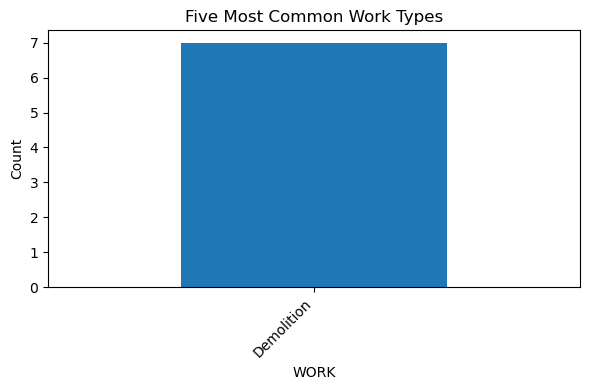

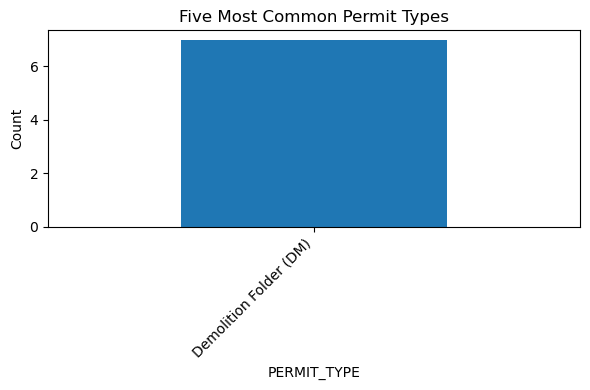

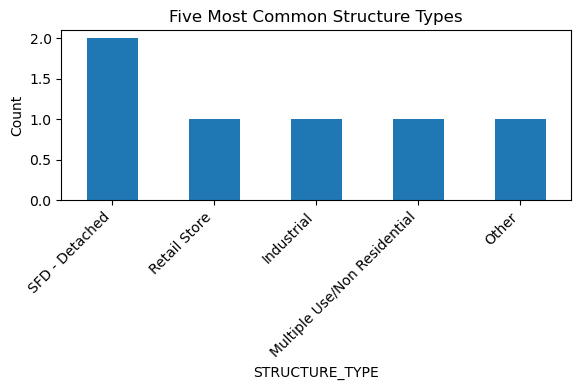

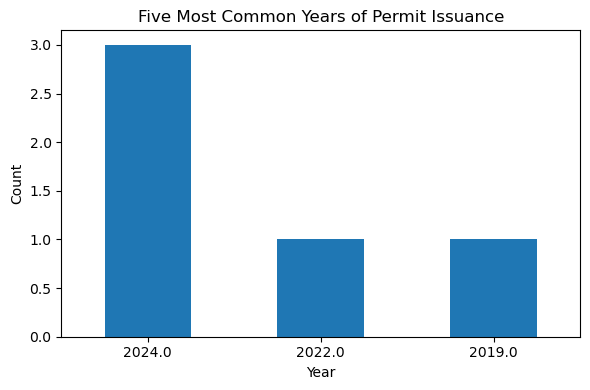

In [42]:
# summarise the data in the active building permits dataset

import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
filtered_demolition_df["ISSUED_DATE"] = pd.to_datetime(filtered_demolition_df["ISSUED_DATE"], errors="coerce")
filtered_demolition_df["APPLICATION_DATE"] = pd.to_datetime(filtered_demolition_df["APPLICATION_DATE"], errors="coerce")
filtered_demolition_df["COMPLETED_DATE"] = pd.to_datetime(filtered_demolition_df["COMPLETED_DATE"], errors="coerce")

# Extract years
filtered_demolition_df["ISSUED_YEAR"] = filtered_demolition_df["ISSUED_DATE"].dt.year
filtered_demolition_df["APPLICATION_YEAR"] = filtered_demolition_df["APPLICATION_DATE"].dt.year

# Plot top Work types
work_counts = filtered_demolition_df["WORK"].value_counts()
plt.figure(figsize=(6,4))
work_counts = work_counts.head(5)
work_counts.plot(kind="bar")
plt.title("Five Most Common Work Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top Permit types
permit_counts = filtered_demolition_df["PERMIT_TYPE"].value_counts()
plt.figure(figsize=(6,4))
permit_counts = permit_counts.head(5)
permit_counts.plot(kind="bar")
plt.title("Five Most Common Permit Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot top structure types
structure_counts = filtered_demolition_df["STRUCTURE_TYPE"].value_counts()
plt.figure(figsize=(6,4))
structure_counts = structure_counts.head(5)
structure_counts.plot(kind="bar")
plt.title("Five Most Common Structure Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot issuance year trend
year_counts = filtered_demolition_df["ISSUED_YEAR"].value_counts()
plt.figure(figsize=(6,4))
year_counts = year_counts.head(5)
year_counts.plot(kind="bar")
plt.title("Five Most Common Years of Permit Issuance")
plt.ylabel("Count")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## PCA

Cluster 2: points=2, mean dist=3.610, std dist=0.000
Cluster 1: points=3, mean dist=2.302, std dist=1.628
Cluster 3: points=1, mean dist=nan, std dist=nan
Cluster 4: points=1, mean dist=nan, std dist=nan


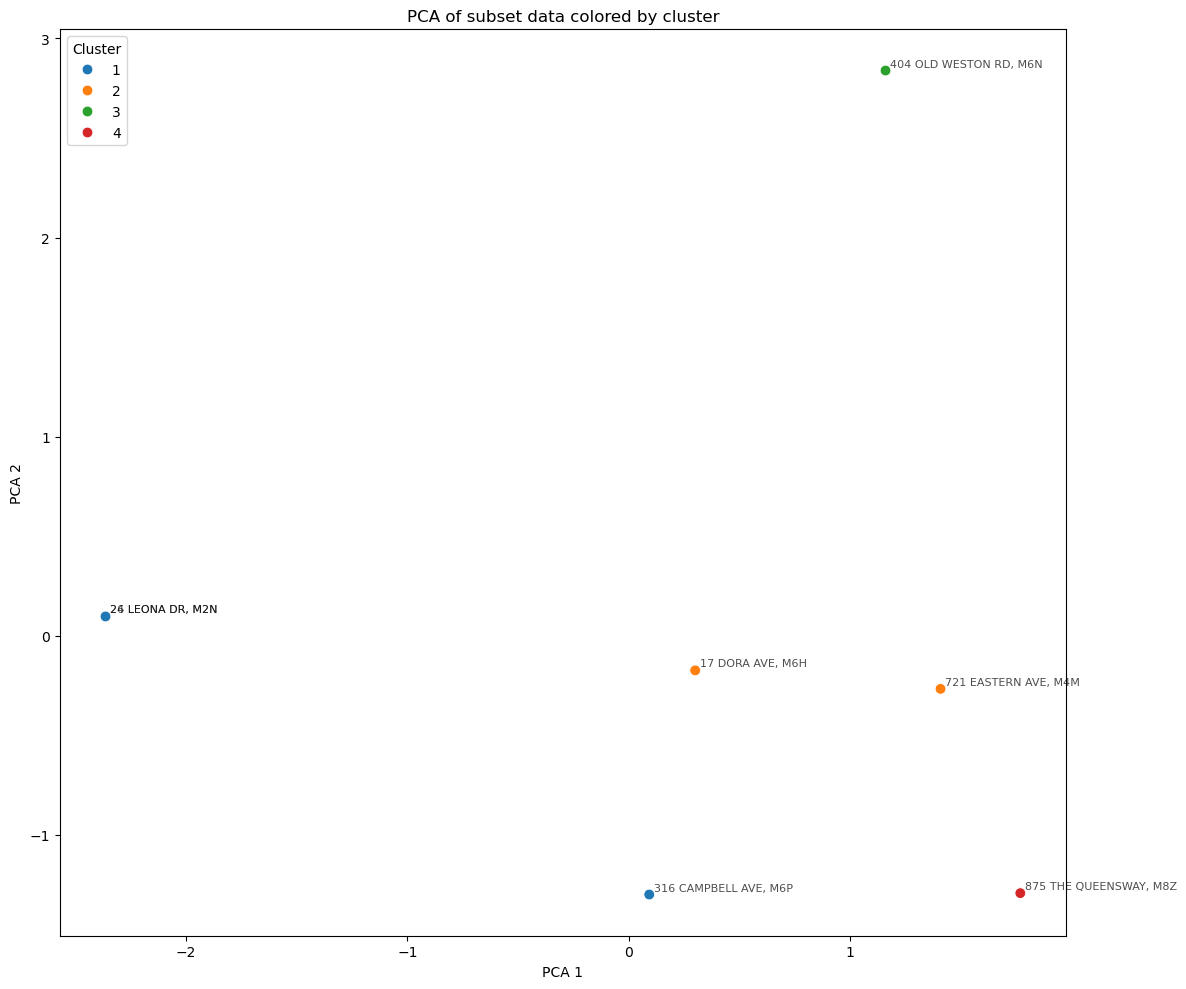

In [43]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

subset_df_scaled_demolition = building_vectors_demolition.copy()
scaler = StandardScaler()
subset_df_scaled_demolition[feature_names_demolition] = scaler.fit_transform(subset_df_scaled_demolition[feature_names_demolition])

# Dictionary to hold cluster stats
cluster_stats = {}

for cluster in subset_df_scaled_demolition['cluster_label'].unique():
    cluster_data = subset_df_scaled_demolition[subset_df_scaled_demolition['cluster_label'] == cluster]
    if len(cluster_data) > 1: # big-clusters
        dist_matrix = pairwise_distances(cluster_data[feature_names_demolition], metric='euclidean')
        # avoid zero distances
        dists = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
        cluster_stats[cluster] = {
            'mean_distance': np.mean(dists),
            'std_distance': np.std(dists),
            'num_points': len(cluster_data)
        }
    else: # Single point cluster: distances undefined
        cluster_stats[cluster] = {
            'mean_distance': np.nan,
            'std_distance': np.nan,
            'num_points': 1
        }

# Print cluster stats
for cluster, stats in cluster_stats.items():
    print(f"Cluster {cluster}: points={stats['num_points']}, mean dist={stats['mean_distance']:.3f}, std dist={stats['std_distance']:.3f}")

# Visualize in low dimensions.  There's not great separation, sadly, but whatevs
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(subset_df_scaled_demolition[feature_names_demolition])
subset_df_scaled_demolition['pca1'] = coords_2d[:, 0]
subset_df_scaled_demolition['pca2'] = coords_2d[:, 1]

# Plot with cluster coloring
plt.figure(figsize=(12, 10))
sns.scatterplot(data=subset_df_scaled_demolition, x='pca1', y='pca2', hue='cluster_label', palette='tab10', s=60)

# Add ADDRESS labels to each point
for _, row in subset_df_scaled_demolition.iterrows():
    plt.text(row['pca1'] + 0.02, row['pca2'] + 0.02, str(row['FULL_ADDRESS']), fontsize=8, alpha=0.7)

plt.title('PCA of subset data colored by cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## Decision Tree Classifier

Training Accuracy: 1.0
y_train: 0    2
1    1
2    1
3    1
4    3
5    2
6    4
Name: cluster_label, dtype: int64
predictions: [2 1 1 1 3 2 4]
       predicted_class  confidence      _id  REVISION_NUM       GEO_ID  \
10986                1         1.0    13538             0     335328.0   
32748                1         1.0   480671             1     105488.0   
61614                1         1.0   487847             0   27115758.0   
44444                2         1.0   180025             0    7930156.0   
56705                2         1.0    33522             0    7792475.0   
27568                2         1.0  2119483             0    1073632.0   
5116                 3         1.0  1106786             0   64532776.0   
41810                3         1.0   561377             2  119797410.0   
15390                3         1.0    23909             0  103792000.0   
4650                 4         1.0   497819             0   71202205.0   
67478                4         1.0   46353

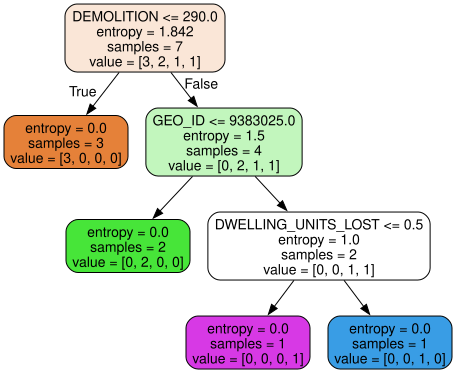

In [44]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# the buildings in the beautiful data set
X_train = building_vectors_demolition[feature_names_demolition].copy()
y_train = building_vectors_demolition['cluster_label'].copy()

# the ENTIRE data set
X_test = df_grouped[feature_names_demolition].copy()
addresses = df_grouped["FULL_ADDRESS"]

# limit the depth of the tree to 3 to avoid overfitting.
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))

predictions = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions}")

# Get predicted probabilities for each class
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

# Build a result DataFrame with predictions and confidence
results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

top_n = 3
top_confident_per_class = []

# Loop through each class
for cls, group in results.groupby('predicted_class'):
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    # Randomly select n samples
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

top_confident_per_class = pd.concat(top_confident_per_class)

print(top_confident_per_class)

dot_data = treeViz.export_graphviz(model, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))


## Random Forest 
- Do not worry too much about the Random Forest 
- Keep working on draft, explain process of what's happening here 
- Focus on displaying results

Training Accuracy: 1.0
y_train: 0    2
1    1
2    1
3    1
4    3
5    2
6    4
Name: cluster_label, dtype: int64
predictions: [2 1 1 1 3 2 4]
       predicted_class  confidence     _id  REVISION_NUM      GEO_ID  \
10481                1    0.830000    7041             0    854469.0   
31644                1    0.830000    5260             0    536668.0   
19964                1    0.830000   17985             0   1121433.0   
46560                2    0.661667  118616             0   7667909.0   
46468                3    0.470000  155883             0  28077516.0   
55848                4    0.620000  157325             0  11382489.0   
8578                 4    0.620000  151845             0  10636263.0   

       DWELLING_UNITS_CREATED  DWELLING_UNITS_LOST  ASSEMBLY  INSTITUTIONAL  \
10481                     0.0                  1.0       0.0            0.0   
31644                     0.0                  1.0       0.0            0.0   
19964                     1.0             

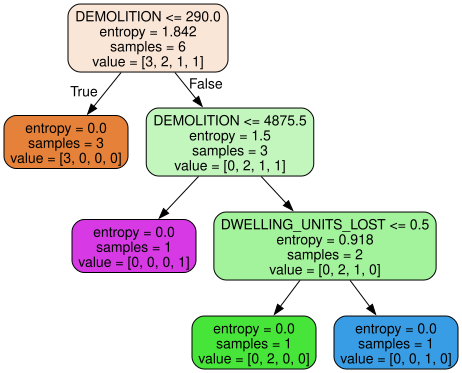

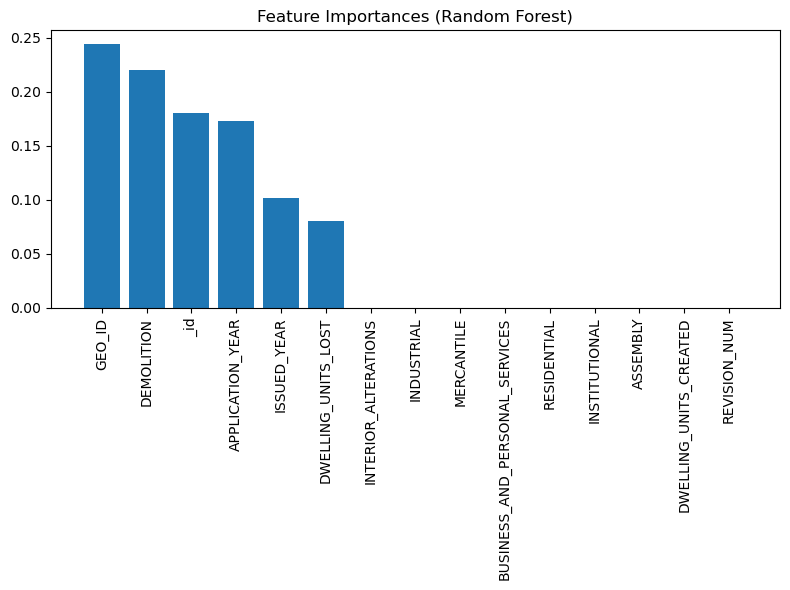

In [45]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
os.environ["PATH"] += os.pathsep + graphviz_bin_path

# the buildings in the beautiful data set
X_train = building_vectors_demolition[feature_names_demolition].copy()
y_train = building_vectors_demolition['cluster_label'].copy()

# the ENTIRE data set
X_test = df_grouped[feature_names_demolition].copy()
addresses = df_grouped["FULL_ADDRESS"]

# limit the depth of the tree to 3 to avoid overfitting.
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, criterion='entropy')
model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))

predictions = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions}")

# Get predicted probabilities for each class
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

# Build a result DataFrame with predictions and confidence
results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

top_n = 3
top_confident_per_class = []

# Loop through each class
for cls, group in results.groupby('predicted_class'):
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    # Randomly select n samples
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

top_confident_per_class = pd.concat(top_confident_per_class)

print(top_confident_per_class)

# Visualize a single tree from the RandomForest
estimator = model.estimators_[50]
dot_data = treeViz.export_graphviz(estimator, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))

# Alternative: Feature importance plot for the whole forest
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


# Applying previous DTC to demolition-only general dataset

Training Accuracy: 1.00
y_train: 0     2
1     2
2     1
3     1
4     1
5     1
6     1
7     2
8     2
9     2
10    3
11    3
12    2
13    4
Name: cluster_label, dtype: int64
predictions: [2 2 1 1 1 1 1 2 2 2 3 3 2 4]
      predicted_class  confidence     _id  REVISION_NUM      GEO_ID  \
1857                1         1.0  202403             0    521378.0   
1113                1         1.0  216019             0     70804.0   
2687                1         1.0  195684             0   3599983.0   
1365                2         1.0  226925             0   4950663.0   
259                 2         1.0    6089             0    339445.0   
2122                2         1.0  237602             0  10486883.0   
1911                3         1.0    4754             0  30044914.0   
468                 3         1.0   74352             0  30095711.0   
2560                3         1.0  110444             0  30023975.0   

      DWELLING_UNITS_CREATED  DWELLING_UNITS_LOST  ASSEMBLY  INSTIT

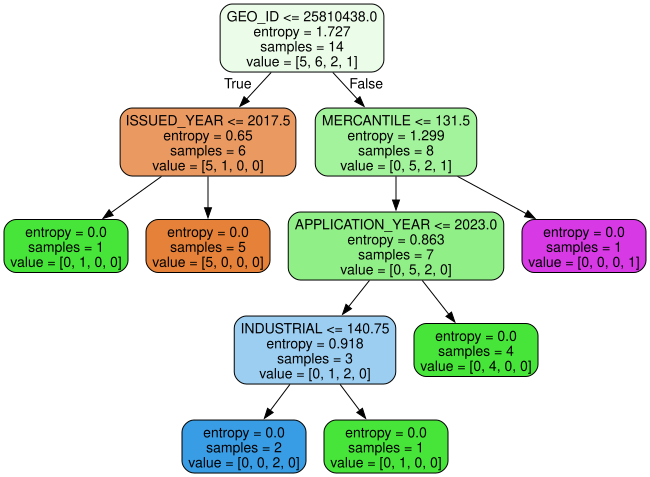

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as treeViz
import graphviz
from IPython.display import display
import os

# Update graphviz path
graphviz_bin_path = r'C:\Users\asu\Downloads\blogathon\large_files\Graphviz\bin'
if graphviz_bin_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + graphviz_bin_path

# --- STEP 1: TRAINING DATA (Use ALL personal buildings) ---
# We keep all 15 personal buildings for training.
X_train = building_vectors[feature_names].copy()
y_train = building_vectors['cluster_label'].copy()

# --- STEP 2: TARGET DATA (Filter by String 'Demolition Folder (DM)') ---
# 1. Filter the RAW dataframe first
demolition_desc_df = df[df['PERMIT_TYPE'] == 'Demolition Folder (DM)'].copy()

# 2. Select numeric columns & Group
numeric_demo_df = demolition_desc_df.select_dtypes(include=['number'])
numeric_demo_df['FULL_ADDRESS'] = demolition_desc_df['FULL_ADDRESS']
target_pool = numeric_demo_df.groupby("FULL_ADDRESS").sum().reset_index()

# 3. FIX: Calculate TOTAL_PERMITS and add it back
permit_counts = demolition_desc_df.groupby("FULL_ADDRESS").size().reset_index(name='TOTAL_PERMITS')
target_pool = target_pool.merge(permit_counts, on='FULL_ADDRESS')

# 4. Define X_test
X_test = target_pool[feature_names].copy()
addresses = target_pool["FULL_ADDRESS"]

# --- STEP 3: TRAIN MODEL ---
model = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
model.fit(X_train, y_train)

print(f"Training Accuracy: {model.score(X_train, y_train):.2f}")

# Match old code debug output
predictions_train = model.predict(X_train)
print(f"y_train: {y_train}")
print(f"predictions: {predictions_train}")

# --- STEP 4: PREDICT ---
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
predicted_class = model.predict(X_test)

results = pd.DataFrame({
    'predicted_class': predicted_class,
    'confidence': confidences
}, index=X_test.index)

results = results.join(X_test)
results = results.join(addresses)

# --- STEP 5: SHOW RESULTS (Matched Logic) ---
top_n = 3
top_confident_per_class = []

for cls, group in results.groupby('predicted_class'):
    # 1. Find max confidence for this class
    max_conf = group['confidence'].max()
    top_confident = group[group['confidence'] == max_conf]
    
    # 2. Randomly sample from the best matches
    sampled = top_confident.sample(n=min(top_n, len(top_confident)), random_state=42)
    top_confident_per_class.append(sampled)

if top_confident_per_class:
    final_display = pd.concat(top_confident_per_class)
    # Print the full dataframe (all columns) just like the old code
    print(final_display)
else:
    print("No matches found.")



# Visualize the Tree
dot_data = treeViz.export_graphviz(model, max_depth=4, feature_names=X_train.columns.tolist(), filled=True, rounded=True)
display(graphviz.Source(dot_data))

In [14]:
print(f"Max Cost in Training Set: ${X_train['EST_CONST_COST'].max():,.0f}")
print(f"Max Cost in Demolition Set: ${X_test['EST_CONST_COST'].max():,.0f}")

Max Cost in Training Set: $110,000,000
Max Cost in Demolition Set: $7,500,000


# Cluster 1 
- 44 Herne Hill : looks like a really nice put-together house, Street View from 2022 
- 139 Chisholme Ave: looks like a really nice put-together house, Street View from 2020 
- 30 Hawksbury Drive: also looks like a pretty nice house - however, the plants out front are very overgrown! Street View from 2022, ALSO HAS DEMOLITION ASSOCIATED WITH IT 

# Cluster 2 
- 123 Parkway Forest Drive: looks like a set of clean apartments... Street View from May 2025 
- 4080 Sheppard Avenue E: looks like a parking lot... Street View from 2020 
- 30 Donlands Avenue: uh, this is the Donlands TTC station... Street View 2021 

# Cluster 3 
- 677 Richmond Street W: looks like a pretty nice house... Street View from 2023. I have a better feeling about this one for some reason. 
- 278 Brunswick Ave: also looks like a pretty nice house. Street View from 2024...
- 33 Russett Ave: a house under construction. Street View from 2024. 

# Cluster 4 
- 3401 Dufferin St: This is the Yorkdale Mall. Demolition is associated with it, but it's the Yorkdale Mall...
- 2900 Warden Ave: This is the Bridlewood Mall. 
- 2200 Lake Shore Blvd. W: Looks like a large apartment building? Street View from 2024. 